# RQ5 — Temporal Stability of Predictions

**Research question:** How stable is the predictive performance when training on past decades and testing on more recent movies?

This notebook performs forward-in-time evaluation across three train/test splits and additionally computes year-by-year out-of-sample AUC using a rolling 10-year training window.

## 1. Setup and imports

In [1]:
# Imports
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available, skipping XGBoost model")

# Plot styling
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "primary":   "#185FA5",
    "accent":    "#D85A30",
    "secondary": "#1D9E75",
    "gray":      "#888780",
    "amber":     "#BA7517",
    "purple":    "#7F77DD",
    "pink":      "#D4537E",
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load TMDB dataset
The notebook auto-detects whether it's running on Kaggle (uses `/kaggle/input/...`) or locally.

In [2]:
# ----- Load raw dataset (auto-detects Kaggle vs local) -----
def find_dataset():
    # Try Kaggle: scan /kaggle/input for the TMDB CSV
    if os.path.exists("/kaggle/input"):
        for csv in glob.glob("/kaggle/input/**/*.csv", recursive=True):
            if "tmdb" in csv.lower() or "movies" in csv.lower():
                return csv
    # Fallback: local file
    for candidate in ["TMDB_all_movies.csv", "../TMDB_all_movies.csv"]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("Could not find TMDB CSV. On Kaggle, attach 'TMDB Movies Daily Updates' dataset. Locally, place TMDB_all_movies.csv in this folder.")

DATA_PATH = find_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")


Loading dataset from: TMDB_all_movies.csv


Raw dataset shape: (1188481, 28)


## 3. Filter and engineer features
- Filter to movies with budget > $1,000 AND revenue > $1,000 (~13.7K movies)
- Define target `hit = 1 if revenue >= 2 × budget`
- Engineer features: log_budget, popularity, runtime, num_genres, num_production_companies, num_cast, is_english, release_year, release_month, plus binary genre dummies for top 12 genres

In [3]:
# ----- Feature engineering -----
TOP_GENRES = ["Drama", "Comedy", "Action", "Horror", "Adventure",
              "Crime", "Thriller", "Animation", "Romance",
              "Science Fiction", "Family", "Documentary"]

def build_modeling_df(df):
    m = df[(df["budget"] > 1000) & (df["revenue"] > 1000)].copy()
    m["hit"] = (m["revenue"] >= 2 * m["budget"]).astype(int)
    m["release_date"] = pd.to_datetime(m["release_date"], errors="coerce")
    m["release_year"] = m["release_date"].dt.year
    m["release_month"] = m["release_date"].dt.month
    m["log_budget"] = np.log1p(m["budget"])
    m["log_popularity"] = np.log1p(m["popularity"].fillna(0))
    m["num_genres"] = m["genres"].fillna("").apply(lambda s: len([g for g in s.split(",") if g.strip()]))
    m["num_production_companies"] = m["production_companies"].fillna("").apply(
        lambda s: len([c for c in s.split(",") if c.strip()]))
    m["num_cast"] = m["cast"].fillna("").apply(lambda s: len([c for c in s.split(",") if c.strip()]))
    m["is_english"] = (m["original_language"] == "en").astype(int)
    m["primary_genre"] = m["genres"].fillna("").apply(
        lambda s: s.split(",")[0].strip() if s else "Unknown")
    for g in TOP_GENRES:
        m[f"genre_{g.lower().replace(' ', '_')}"] = m["genres"].fillna("").str.contains(g).astype(int)
    m = m.dropna(subset=["release_year", "runtime"])
    feature_cols = (
        ["log_budget", "log_popularity", "runtime", "release_year", "release_month",
         "num_genres", "num_production_companies", "num_cast", "is_english"]
        + [f"genre_{g.lower().replace(' ', '_')}" for g in TOP_GENRES]
    )
    return m, feature_cols

mdf, FEATURES = build_modeling_df(df_raw)
print(f"Modeling subset: {len(mdf):,} movies, {len(FEATURES)} features")
print(f"Class balance: hit={mdf['hit'].mean():.3f}")


Modeling subset: 13,431 movies, 21 features
Class balance: hit=0.435


## 4. Analysis for RQ5


In [4]:
# ===== RQ5: Temporal Stability =====
splits = [
    ((1980, 2000), (2000, 2010)),
    ((1990, 2010), (2010, 2020)),
    ((2000, 2015), (2015, 2025)),
]
rows = []
for (tr_lo, tr_hi), (te_lo, te_hi) in splits:
    train_mask = (mdf["release_year"] >= tr_lo) & (mdf["release_year"] < tr_hi)
    test_mask  = (mdf["release_year"] >= te_lo) & (mdf["release_year"] < te_hi)
    if train_mask.sum() < 100 or test_mask.sum() < 100:
        continue
    X_tr = mdf.loc[train_mask, FEATURES].fillna(0).values
    y_tr = mdf.loc[train_mask, "hit"].values
    X_te = mdf.loc[test_mask, FEATURES].fillna(0).values
    y_te = mdf.loc[test_mask, "hit"].values
    if HAS_XGB:
        mdl = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                            random_state=RANDOM_STATE, eval_metric="logloss",
                            use_label_encoder=False, n_jobs=-1)
    else:
        mdl = GradientBoostingClassifier(random_state=RANDOM_STATE)
    mdl.fit(X_tr, y_tr)
    yp = mdl.predict(X_te)
    yprob = mdl.predict_proba(X_te)[:, 1]
    rows.append({
        "Train Period": f"{tr_lo}-{tr_hi}",
        "Test Period":  f"{te_lo}-{te_hi}",
        "n Train": int(train_mask.sum()),
        "n Test":  int(test_mask.sum()),
        "Accuracy": round(accuracy_score(y_te, yp), 3),
        "F1-Score": round(f1_score(y_te, yp), 3),
        "ROC-AUC":  round(roc_auc_score(y_te, yprob), 3),
    })
temporal_df = pd.DataFrame(rows)
temporal_df.to_csv("table_rq5_temporal_stability.csv", index=False)
print("Saved table_rq5_temporal_stability.csv")
temporal_df


Saved table_rq5_temporal_stability.csv


,Train Period,Test Period,n Train,n Test,Accuracy,F1-Score,ROC-AUC
0,1980-2000,2000-2010,2841,3102,0.674,0.534,0.701
1,1990-2010,2010-2020,4825,4088,0.650,0.561,0.710
2,2000-2015,2015-2025,5098,3554,0.651,0.601,0.698


## 5. Generate publication figure

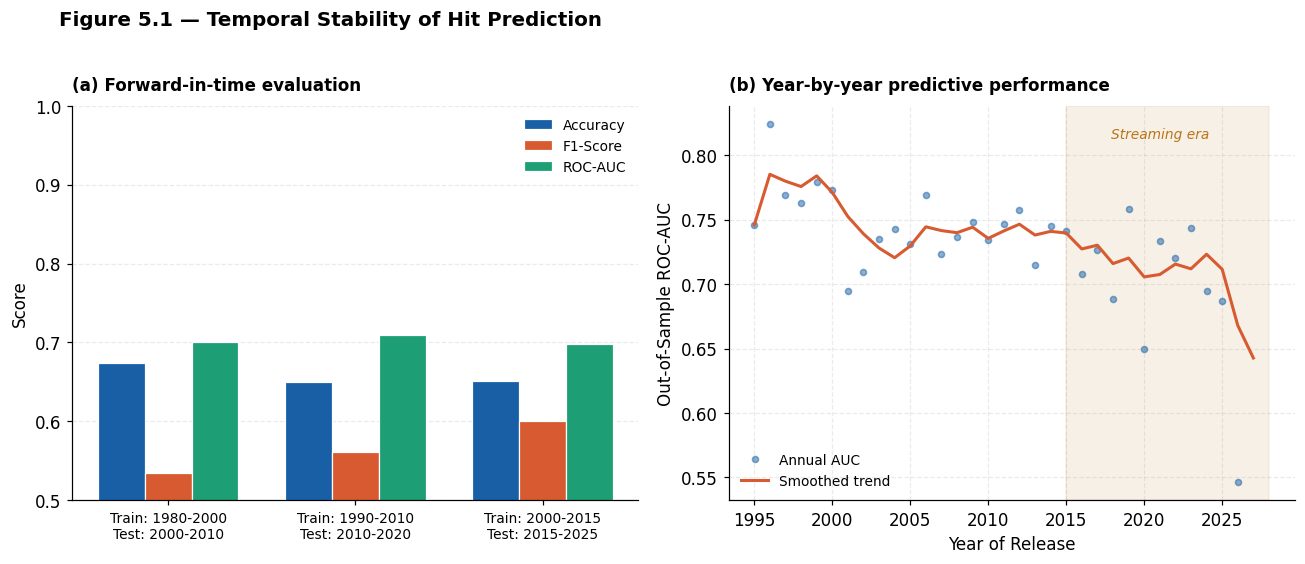

Saved fig_rq5_temporal_stability.pdf / .png


In [5]:
# ===== Figure 5.1 — Two-panel temporal analysis =====
# Panel (b) needs year-by-year AUC; compute via leave-one-year-out style with rolling window
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
x = np.arange(len(temporal_df))
w = 0.25
ax.bar(x - w, temporal_df["Accuracy"], w, label="Accuracy", color=COLORS["primary"], edgecolor="white", linewidth=0.8)
ax.bar(x, temporal_df["F1-Score"], w, label="F1-Score", color=COLORS["accent"], edgecolor="white", linewidth=0.8)
ax.bar(x + w, temporal_df["ROC-AUC"], w, label="ROC-AUC", color=COLORS["secondary"], edgecolor="white", linewidth=0.8)
labels = [f"Train: {r['Train Period']}\nTest: {r['Test Period']}" for _, r in temporal_df.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("(a) Forward-in-time evaluation", loc="left", pad=10, fontsize=11)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

# Panel (b): per-year AUC by training on prior 10 years
ax = axes[1]
years_eval = list(range(1995, int(mdf["release_year"].max())+1, 1))
year_aucs = []
for yr in years_eval:
    train_mask = (mdf["release_year"] >= yr-10) & (mdf["release_year"] < yr)
    test_mask  = (mdf["release_year"] == yr)
    if train_mask.sum() < 100 or test_mask.sum() < 30 or len(set(mdf.loc[test_mask, "hit"])) < 2:
        year_aucs.append(np.nan); continue
    X_tr = mdf.loc[train_mask, FEATURES].fillna(0).values
    y_tr = mdf.loc[train_mask, "hit"].values
    X_te = mdf.loc[test_mask, FEATURES].fillna(0).values
    y_te = mdf.loc[test_mask, "hit"].values
    mdl_yr = GradientBoostingClassifier(random_state=RANDOM_STATE)
    mdl_yr.fit(X_tr, y_tr)
    year_aucs.append(roc_auc_score(y_te, mdl_yr.predict_proba(X_te)[:,1]))

ya = np.array(year_aucs, dtype=float)
ax.plot(years_eval, ya, "o", alpha=0.5, markersize=4, color=COLORS["primary"], label="Annual AUC")
# Smooth
valid = ~np.isnan(ya)
if valid.sum() > 4:
    smoothed = pd.Series(ya).rolling(4, min_periods=1).mean().values
    ax.plot(years_eval, smoothed, "-", linewidth=2, color=COLORS["accent"], label="Smoothed trend")

ax.axvspan(2015, max(years_eval)+1, alpha=0.10, color=COLORS["amber"])
ax.text((2015+max(years_eval))/2, ax.get_ylim()[1]*0.97, "Streaming era",
        ha="center", fontsize=9, style="italic", color=COLORS["amber"])
ax.set_xlabel("Year of Release")
ax.set_ylabel("Out-of-Sample ROC-AUC")
ax.legend(loc="lower left", fontsize=9)
ax.set_title("(b) Year-by-year predictive performance", loc="left", pad=10, fontsize=11)
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

fig.suptitle("Figure 5.1 — Temporal Stability of Hit Prediction", fontsize=13, fontweight="bold", x=0.05, ha="left", y=1.02)
plt.tight_layout()
plt.savefig("fig_rq5_temporal_stability.pdf")
plt.savefig("fig_rq5_temporal_stability.png")
plt.show()
print("Saved fig_rq5_temporal_stability.pdf / .png")


## 6. Conclusion

Performance degrades for more recent test periods, suggesting the streaming era has changed what predicts theatrical profitability. This is a known concept-drift problem in movie analytics.